<a href="https://colab.research.google.com/github/nev12/gym-dropout-prediction/blob/main/02_data_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gym Data Validation

Verifying that the data generation actually worked, and that the data can be used for a churn prediction.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import files

uploaded = files.upload()

dfs = {}
for filename in uploaded.keys():
  dfs[filename] = pd.read_csv(filename)

Saving checkins.csv to checkins.csv
Saving gym_locations_data.csv to gym_locations_data.csv
Saving subscription_plans.csv to subscription_plans.csv
Saving users.csv to users.csv


In [3]:
checkins = dfs['checkins.csv']
gyms = dfs['gym_locations_data.csv']
subs = dfs['subscription_plans.csv']
users = dfs['users.csv']

In [4]:
checkins

,user_id,gym_id,checkin_time,checkout_time,workout_type,calories_burned
0,user_1,gym_5,2025-03-10 13:34:24.772586,2025-03-10 15:10:20.758410,HIIT,788
1,user_1,gym_5,2025-03-19 23:38:15.534797,2025-03-20 00:43:51.251958,HIIT,524
2,user_1,gym_5,2025-03-22 05:02:09.218276,2025-03-22 06:40:17.282516,HIIT,871
3,user_1,gym_5,2025-03-28 02:38:09.364221,2025-03-28 03:45:53.845731,HIIT,606
4,user_1,gym_5,2025-03-29 04:16:17.789664,2025-03-29 05:50:28.107983,HIIT,612
...,...,...,...,...,...,...
237730,user_5000,gym_4,2025-11-12 07:53:32.555926,2025-11-12 09:32:25.594696,HIIT,902
237731,user_5000,gym_4,2025-12-08 14:01:24.306720,2025-12-08 15:41:29.008786,Yoga,744
237732,user_5000,gym_9,2025-12-12 00:20:15.083703,2025-12-12 01:45:49.237966,Yoga,599
237733,user_5000,gym_3,2025-12-18 03:11:18.144847,2025-12-18 04:28:34.169634,HIIT,628


In [5]:
users

,user_id,user_type,signup_date
0,user_1,casual,2025-02-20
1,user_2,at_risk,2025-02-09
2,user_3,sporadic,2025-01-07
3,user_4,casual,2025-02-01
4,user_5,consistent,2025-02-17
...,...,...,...
4995,user_4996,at_risk,2025-01-19
4996,user_4997,consistent,2025-01-16
4997,user_4998,casual,2025-01-21
4998,user_4999,sporadic,2025-01-02


In [6]:
users['signup_date'] = pd.to_datetime(users['signup_date'])
checkins['checkin_time'] = pd.to_datetime(checkins['checkin_time'])
checkins['checkout_time'] = pd.to_datetime(checkins['checkout_time'])

## 1. Structural Integrity Checks


In [7]:
N_USERS = 5000
assert len(users) == N_USERS, "unexpected number of users"
assert users['user_id'].is_unique, "duplicate user_ids found"
assert users[['user_id', 'signup_date']].isna().sum().sum() == 0, "missing values in user table"

In [8]:
checkins_columns = [
    'user_id',
    'gym_id',
    'checkin_time',
    'checkout_time',
    'workout_type'
]
assert checkins[checkins_columns].isna().sum().sum() == 0, "missing values in user table"
assert (checkins['checkout_time'] > checkins['checkin_time']).all(), "found checkout time before checkin_time"
assert checkins['checkin_time'].between(
    pd.Timestamp("2025-01-01"),
    pd.Timestamp("2025-12-31")
).all(), "check-ins times outside the expected range"

- Structural integrity checks passed successfully!

## 2. Engagement volume validation

In [9]:
user_activity = (
    checkins
    .groupby('user_id')
    .size()
    .rename('total_checkins')
    .reset_index()
)

user_activity = user_activity.merge(
    users[['user_id', 'user_type']],
    on = 'user_id',
    how = 'left'
)

engagement_by_type = (
    user_activity
    .groupby('user_type')['total_checkins']
    .agg(['mean', 'median', 'std', 'count'])
    .sort_values('mean', ascending=False)
)

engagement_by_type

,mean,median,std,count
user_type,,,,
consistent,77.689092,73.0,15.326682,1531
casual,47.999422,48.0,7.473609,1730
sporadic,23.915758,24.0,5.081463,1009
at_risk,15.921918,16.0,4.229453,730


- Engagement volume is just how it should be, where consistent members have the highest number of checkins, casuals a bit less, sporadic even more, and at risk members have a low number of check-ins

## 3. Gap statistics

Text(0, 0.5, 'number of users')

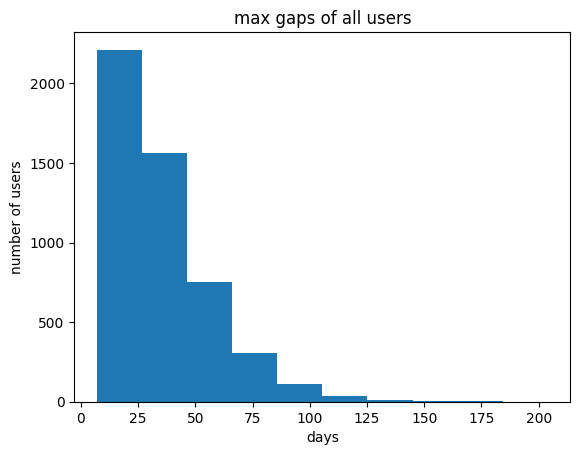

In [10]:
checkins = checkins.sort_values(["user_id", "checkin_time"])

checkins['gap_days'] = checkins.groupby("user_id")["checkin_time"].diff().dt.days
gaps = checkins.groupby("user_id")["gap_days"].max()

plt.hist(gaps)
plt.title("max gaps of all users")
plt.xlabel("days")
plt.ylabel("number of users")

- Now this histogram shows us data which we could acctually use, where gaps arent as frequent as they were before.

## 4. Churn Rate Validation

Text(0, 0.5, 'number of users')

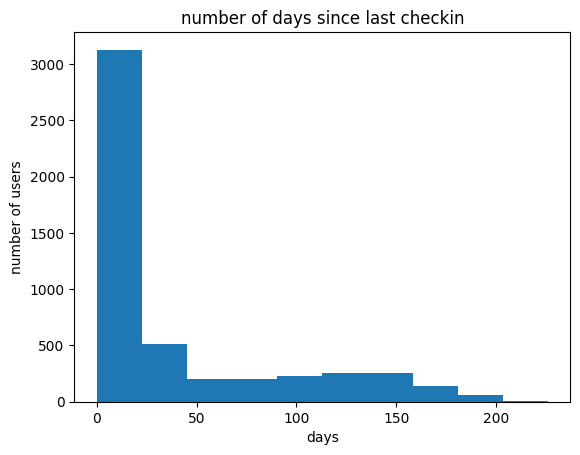

In [11]:
CHURN_DAYS = 21

last_checkin = (
    checkins
    .groupby('user_id')['checkin_time']
    .max()
    .reset_index(name='last_checkin_time')
)

REFERENCE_DATE = pd.Timestamp('2025-12-31')

last_checkin['days_since_last_checkin'] = (REFERENCE_DATE - last_checkin['last_checkin_time']).dt.days
last_checkin.sort_values('days_since_last_checkin')

plt.hist(last_checkin['days_since_last_checkin'])
plt.title("number of days since last checkin")
plt.xlabel("days")
plt.ylabel("number of users")

In [12]:
print("for ", (last_checkin['days_since_last_checkin'] >= 21).sum(), " users, passed more than 21 days since last checkin")
print("for ", (last_checkin['days_since_last_checkin'] < 21).sum(), " users, passed less than 21 days since last checkin")

for  1955  users, passed more than 21 days since last checkin
for  3045  users, passed less than 21 days since last checkin


- This dataset is well suited for churn prediction modeling using a 21-day inactivity treshold